In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Titanic.csv")

In [4]:
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [6]:
from work_shop.config.config import drop_columns
def drop_cols(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    """
    return df.drop(columns = cols)

In [7]:
# df = drop_cols(df, drop_columns)

In [8]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


<h1>check data type</h1>

In [9]:
df.dtypes

Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin           str
Embarked        str
dtype: object

In [10]:
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtypes":dtypes, "Num_uniqe": n_uniq })

,Dtypes,Num_uniqe
Survived,int64,2
Pclass,int64,3
Sex,str,2
Age,float64,88
SibSp,int64,7
Parch,int64,7
Fare,float64,248
Cabin,str,147
Embarked,str,3


In [11]:
from ps import uniqe
uniqe(df)

,Dtypes,Num_uniqe
Survived,int64,2
Pclass,int64,3
Sex,str,2
Age,float64,88
SibSp,int64,7
Parch,int64,7
Fare,float64,248
Cabin,str,147
Embarked,str,3


In [12]:
cols = ['Pclass', 'Survived', 'SibSp', 'Sex', 'Parch', 'Embarked']
df[cols] = df[cols].astype('category')
pd.DataFrame(df.dtypes).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,category,category,category,float64,category,category,float64,str,category


In [13]:
null = df.isnull()
null

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False


In [14]:
null = df.isnull().sum()
ratio = null / df.shape[0]
pd.DataFrame({"nulls_sum": null, "Ratio": ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
nulls_sum,0.0,0.0,0.0,177.000000,0.0,0.0,0.0,687.000000,2.000000
Ratio,0.0,0.0,0.0,0.198653,0.0,0.0,0.0,0.771044,0.002245


In [15]:
df = df.dropna(subset= ['Embarked'])

In [16]:
df = df.drop("Cabin", axis = 1)

In [17]:
df['Age'] = df["Age"].fillna(df['Age'].median())

In [18]:
null = df.isnull().sum()
ratio = null / df.shape[0]
pd.DataFrame({"nulls_sum": null, "Ratio": ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
nulls_sum,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
num_cols = df.select_dtypes("number").columns
num_cols = ['Age', 'Fare']

In [20]:
nums_col = df.select_dtypes("number").columns
for col in nums_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 + 1.5*IQR
    # print(Q1,Q3)
    lower_outliers = df[df[col]< lower_fence][col].values
    upper_outliers = df[df[col]> upper_fence][col].values
    print(upper_outliers)

[58.  55.  66.  65.  59.  71.  70.5 55.5 61.  56.  58.  59.  62.  58.
 63.  65.  61.  60.  64.  65.  56.  63.  58.  55.  71.  64.  62.  62.
 60.  61.  57.  80.  56.  58.  70.  60.  60.  70.  57.  74.  56. ]
[ 71.2833 263.     146.5208  82.1708  76.7292  83.475   73.5    263.
  77.2875 247.5208  73.5     77.2875  79.2     66.6     69.55    69.55
 146.5208  69.55   113.275   76.2917  90.      83.475   90.      79.2
  86.5    512.3292  79.65   153.4625 135.6333  77.9583  78.85    91.0792
 151.55   247.5208 151.55   110.8833 108.9     83.1583 262.375  164.8667
 134.5     69.55   135.6333 153.4625 133.65    66.6    134.5    263.
  75.25    69.3    135.6333  82.1708 211.5    227.525   73.5    120.
 113.275   90.     120.     263.      81.8583  89.1042  91.0792  90.
  78.2667 151.55    86.5    108.9     93.5    221.7792 106.425   71.
 106.425  110.8833 227.525   79.65   110.8833  79.65    79.2     78.2667
 153.4625  77.9583  69.3     76.7292  73.5    113.275  133.65    73.5
 512.3292  76.7292

In [21]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [22]:
# pip install matplotlib

In [23]:
# pip install seaborn

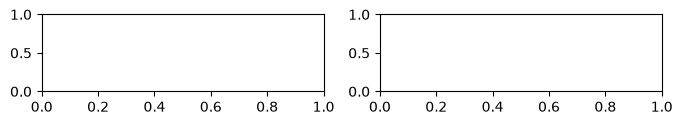

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(8,1))
for i, col in enumerate(nums_col):
    plt.subplot(1,2,i+1)

In [25]:
nums_col = df.select_dtypes("number").columns
for col in nums_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 + 1.5*IQR
    # print(Q1,Q3)
    lower_outliers = df[df[col]< lower_fence][col].values
    upper_outliers = df[df[col]> upper_fence][col].values
    print(upper_outliers)

[58.  55.  66.  65.  59.  71.  70.5 55.5 61.  56.  58.  59.  62.  58.
 63.  65.  61.  60.  64.  65.  56.  63.  58.  55.  71.  64.  62.  62.
 60.  61.  57.  80.  56.  58.  70.  60.  60.  70.  57.  74.  56. ]
[ 71.2833 263.     146.5208  82.1708  76.7292  83.475   73.5    263.
  77.2875 247.5208  73.5     77.2875  79.2     66.6     69.55    69.55
 146.5208  69.55   113.275   76.2917  90.      83.475   90.      79.2
  86.5    512.3292  79.65   153.4625 135.6333  77.9583  78.85    91.0792
 151.55   247.5208 151.55   110.8833 108.9     83.1583 262.375  164.8667
 134.5     69.55   135.6333 153.4625 133.65    66.6    134.5    263.
  75.25    69.3    135.6333  82.1708 211.5    227.525   73.5    120.
 113.275   90.     120.     263.      81.8583  89.1042  91.0792  90.
  78.2667 151.55    86.5    108.9     93.5    221.7792 106.425   71.
 106.425  110.8833 227.525   79.65   110.8833  79.65    79.2     78.2667
 153.4625  77.9583  69.3     76.7292  73.5    113.275  133.65    73.5
 512.3292  76.7292

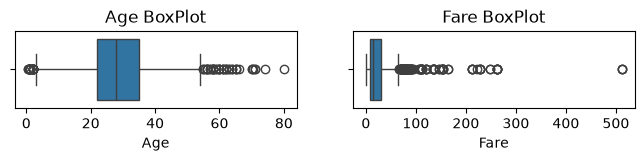

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(8,1))
for i, col in enumerate(nums_col):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col], orient= "h")
    plt.title(f"{col} BoxPlot")

In [27]:
num_col = df.select_dtypes('number').columns
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 + 1.5 *IQR
   
    lower_outliers = df[   df[col] <      lower_fence]    [col].values
    upper_outliers = df[   df[col] >      upper_fence]    [col].values
    print(lower_outliers)
    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)

    

[2.   2.   0.83 2.   1.   1.   1.   2.   2.   0.92 2.   1.   1.   0.75
 2.   2.   2.   0.75 0.67 1.   0.42 2.   1.   0.83]
[]


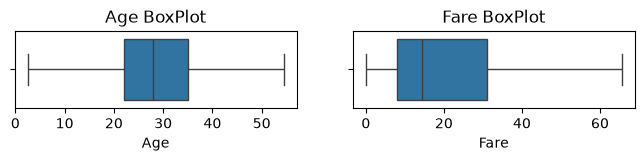

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(8,1))
for i, col in enumerate(nums_col):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col], orient= "h")
    plt.title(f"{col} BoxPlot")

In [29]:
df.duplicated().sum()

np.int64(129)

In [30]:
df = df.drop_duplicates()

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
def remove_duplicated_records(df, subset_cols = None, keep_strategy = "first"):

    count = df.duplicated().sum()
    print(count)

    return (df.drop_duplicates(subset=subset_cols, keep=keep_strategy).reset_index(drop = True).head())

In [33]:
remove_duplicated_records(df)

0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6563,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [34]:
num_col

Index(['Age', 'Fare'], dtype='str')

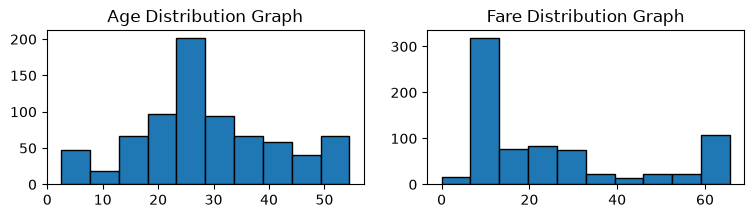

In [35]:
plt.figure(figsize=(9,2))
for i, col in enumerate(num_col):
    plt.subplot(1,2,i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} Distribution Graph")

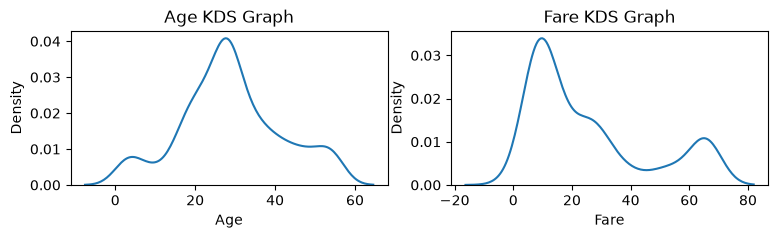

In [36]:
plt.figure(figsize=(9,2))
for i, col in enumerate(num_col):
    plt.subplot(1,2,i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} KDS Graph")

In [37]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

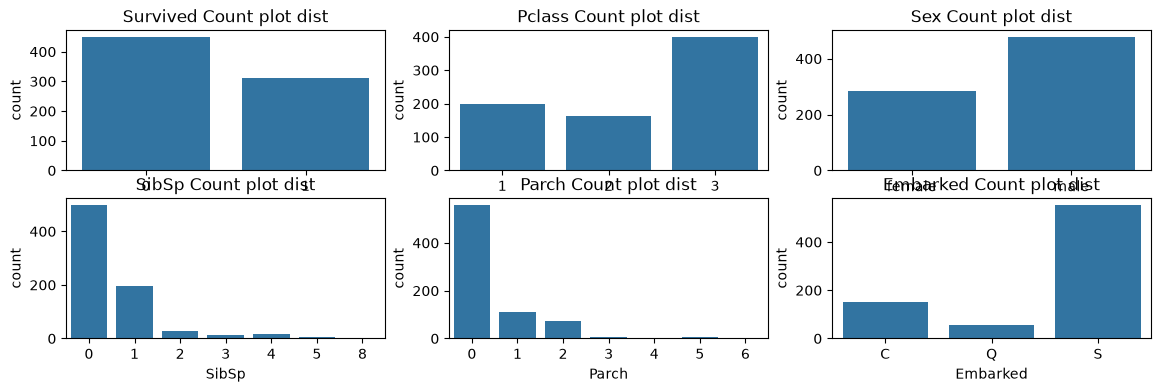

In [38]:
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(x = col, data = df)
    plt.title(f"{col} Count plot dist")

<function matplotlib.pyplot.show(close=None, block=None)>

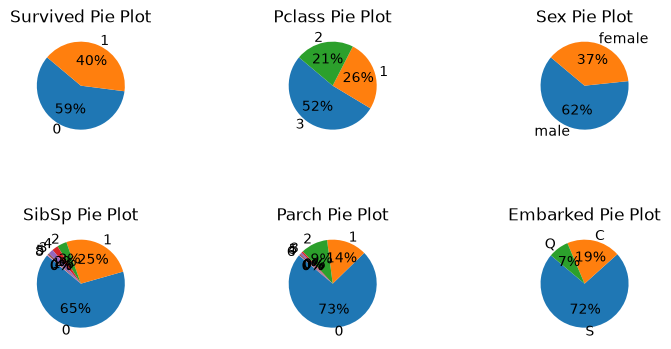

In [39]:
plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count, labels= categories, startangle= 140, autopct= "%1.1d%%")
    plt.title(f"{col} Pie Plot")

plt.subplots_adjust(hspace= 0.8, wspace= 0.3)
plt.show

In [40]:
unique = df[col].value_counts()
count = unique.values
count

array([553, 150,  57])

<function matplotlib.pyplot.show(close=None, block=None)>

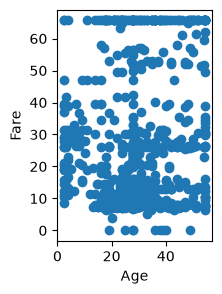

In [41]:
plt.figure(figsize=(2,3))
plt.scatter(df["Age"], df["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show

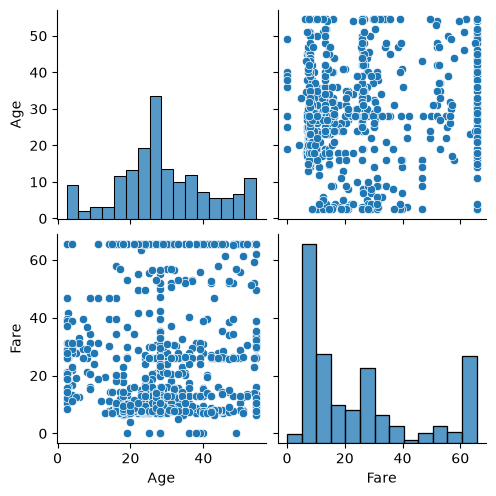

In [42]:
sns.pairplot(df)

In [43]:
corr = df.corr(numeric_only=True)
corr

,Age,Fare
Age,1.000000,0.148527
Fare,0.148527,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

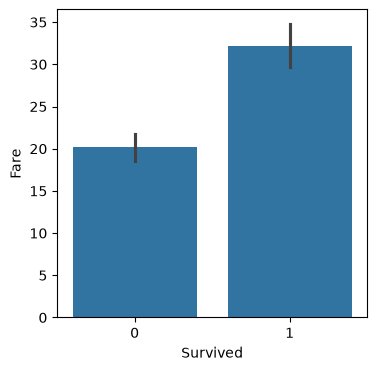

In [44]:
plt.figure(figsize=(4,4))
sns.barplot(x = "Survived", y = "Fare", data = df)
plt.show